In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/xampp/htdocs/ai-drug-price/data/cleaned_data_set/cleaned.csv")


In [2]:
df["Price"].describe()

count     51165.000000
mean        107.662721
std        1153.885654
min           0.100000
25%           6.000000
50%          12.000000
75%          35.110000
max      126000.000000
Name: Price, dtype: float64

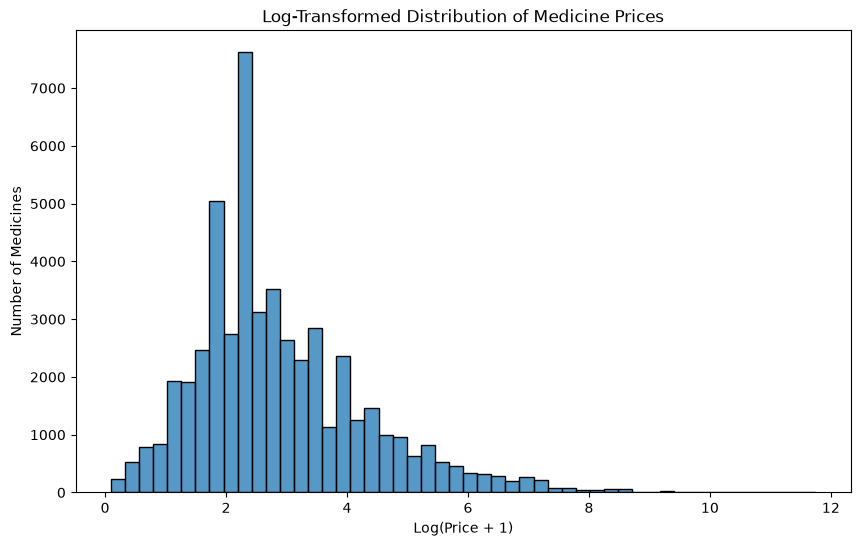

In [3]:
import numpy as np

plt.figure(figsize=(10, 6))

sns.histplot(np.log1p(df["Price"]), bins=50)

plt.title("Log-Transformed Distribution of Medicine Prices")
plt.xlabel("Log(Price + 1)")
plt.ylabel("Number of Medicines")

plt.show()

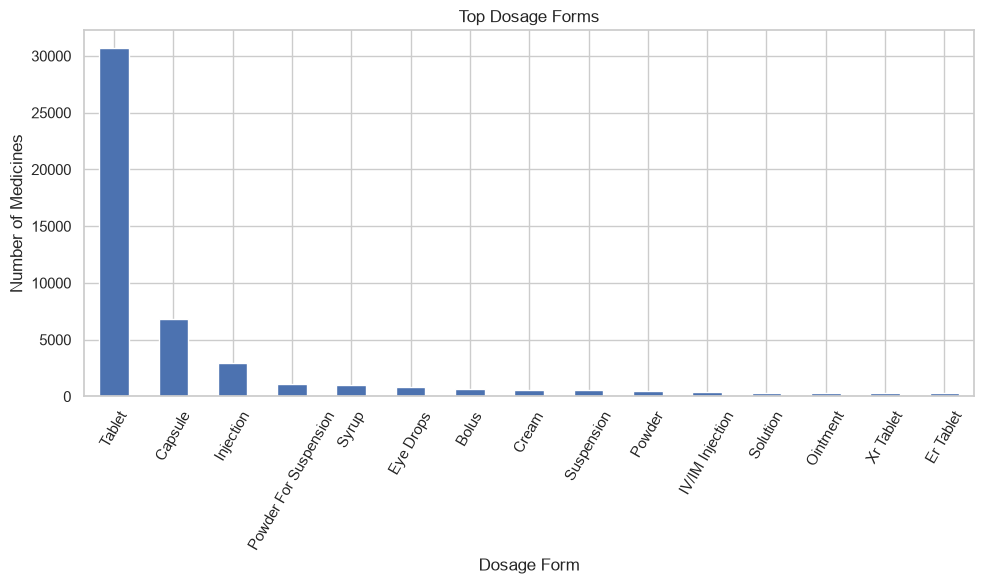

In [9]:
dosage_counts = df["Dosage Description"].value_counts().head(15)

plt.figure(figsize=(10, 6))

dosage_counts.plot(kind="bar")

plt.title("Top Dosage Forms")
plt.xlabel("Dosage Form")
plt.ylabel("Number of Medicines")

plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

In [10]:
dosage_price = (
    df.groupby("Dosage Description")["Price"]
    .agg(["count", "mean", "median"])
    .sort_values("count", ascending=False)
    .head(15)
)

dosage_price

,count,mean,median
Dosage Description,,,
Tablet,30709,26.792753,9.000
Capsule,6799,37.605971,10.000
Injection,2932,918.412364,82.970
Powder For Suspension,1126,137.756581,100.000
Syrup,1032,49.510291,40.000
Eye Drops,837,157.421685,100.000
Bolus,674,15.555490,7.400
Cream,591,120.964992,50.000
Suspension,584,103.980000,35.000


In [11]:
top_generics = df["Generic Name"].value_counts().head(20)

top_generics

Generic Name
Esomeprazole                  931
Ciprofloxacin                 737
Cefixime                      726
Pregabalin                    670
Cefuroxime                    661
Azithromycin                  646
Montelukast                   646
Omeprazole                    643
Etoricoxib                    579
Fexofenadine Hydrochloride    573
Ketorolac Tromethamine        540
Metformin Hydrochloride       511
Fluconazole                   502
Paracetamol                   486
Cephradine                    454
Ceftriaxone                   450
Atorvastatin                  443
Amoxicillin                   417
Diclofenac Sodium             407
Pantoprazole                  402
Name: count, dtype: int64

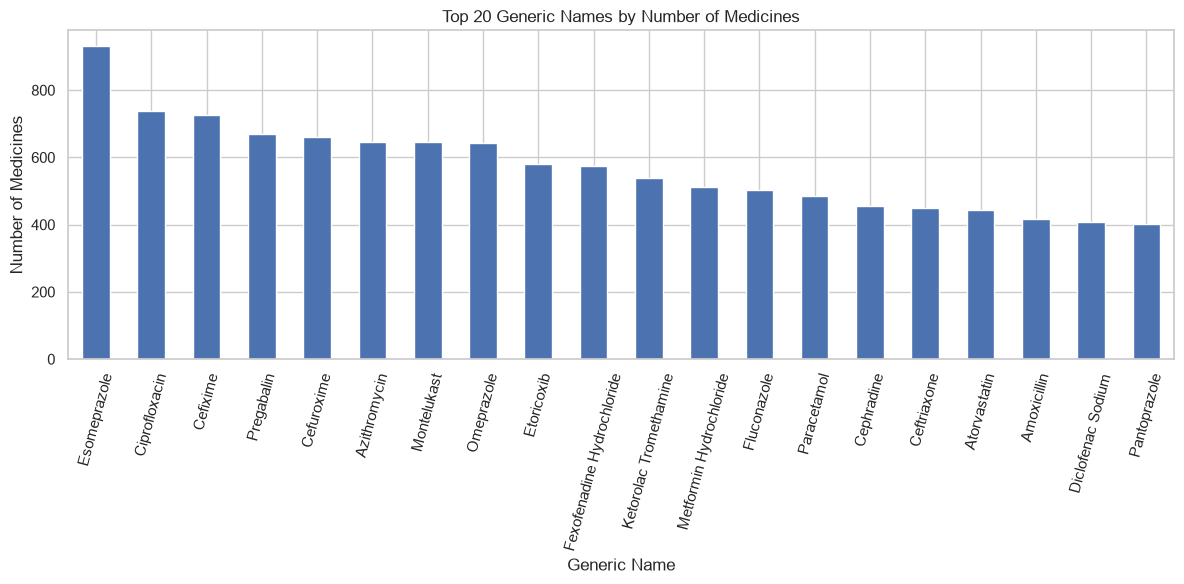

In [12]:
plt.figure(figsize=(12, 6))

top_generics.plot(kind="bar")

plt.title("Top 20 Generic Names by Number of Medicines")
plt.xlabel("Generic Name")
plt.ylabel("Number of Medicines")

plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

In [13]:
generic_price = (
    df.groupby("Generic Name")["Price"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("count", ascending=False)
)

generic_price.head(20)

,count,mean,median,min,max
Generic Name,,,,,
Esomeprazole,931,11.693588,8.000,3.50,120.00
Ciprofloxacin,737,120.534912,18.000,4.55,8522.00
Cefixime,726,80.444904,50.000,19.00,450.00
Pregabalin,670,18.299000,16.000,7.00,220.00
Cefuroxime,661,64.977307,45.000,12.00,350.00
Azithromycin,646,69.057864,35.000,16.00,461.38
Montelukast,646,10.922028,9.000,2.00,43.00
Omeprazole,643,11.347372,6.000,1.47,100.00
Etoricoxib,579,10.951831,12.000,5.50,18.00
